# Test file to check individual slide runs

Test Slide: 001c62abd11fa4b57bf7a6c603a11bb9.tiff

In [ ]:
import openslide

slide = openslide.OpenSlide("../data/panda/001c62abd11fa4b57bf7a6c603a11bb9.tiff")
print(slide.dimensions)

(23904, 28664)


## Patch Extraction

- Grid Sampling (fixed size patches)
- Background Sampling

Output
- patches: images
- coords: spatial positions

In [ ]:
import openslide
import numpy as np

def extract_patches(slide_path, patch_size=224, stride=224, max_patches=300):
    slide = openslide.OpenSlide(slide_path)
    W, H = slide.dimensions
    patches = []
    coords = []
    for x in range(0, W, stride):
        for y in range(0, H, stride):
            patch = slide.read_region((x, y), 0, (patch_size, patch_size))
            patch = np.array(patch)[:, :, :3]
            # Remove white background
            if patch.mean() > 220:
                continue
            
            patches.append(patch)
            coords.append((x, y))
            if len(patches) >= max_patches:
                return np.array(patches), np.array(coords)

    return np.array(patches), np.array(coords)

patches, coords = extract_patches("../data/panda/001c62abd11fa4b57bf7a6c603a11bb9.tiff")
print(patches.shape, coords.shape)

(300, 224, 224, 3) (300, 2)


## Feature Extraction 

ViT-Base-16 pretrained on ImageNet-1K
- 768-dim feature vector per patch

Output -> token embeddings

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import timm

device = 'cuda' if torch.cuda.is_available() else 'cpu'

def extract_features(patches):
    patches_t = torch.tensor(patches / 255.0).permute(0,3,1,2).float()
    vit = timm.create_model('vit_base_patch16_224', pretrained=True)
    vit.head = nn.Identity()
    vit = vit.to(device)
    vit.eval()
    feats = []
    with torch.no_grad():
        for i in range(0, len(patches_t), 32):
            batch = patches_t[i:i+32].to(device)
            feat = vit.forward_features(batch)
            feat = feat.mean(dim=1)
            feats.append(feat.cpu())

    return torch.cat(feats)

/home/sahil-narkhede/Desktop/Me/SEM6/cv/OncoPRISM-Prototype/onco-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
def get_patch_predictions(features):
    # simple linear projection (random but structured)
    linear = nn.Linear(features.shape[1], 1)    
    with torch.no_grad():
        logits = linear(features)
        probs = torch.sigmoid(logits).squeeze()

    return probs.numpy()

In [27]:
features = extract_features(patches)
patch_preds = get_patch_predictions(features)

# combine with pagerank
importance = pr * patch_preds

# normalize
importance = (importance - importance.min()) / (importance.max() - importance.min() + 1e-6)

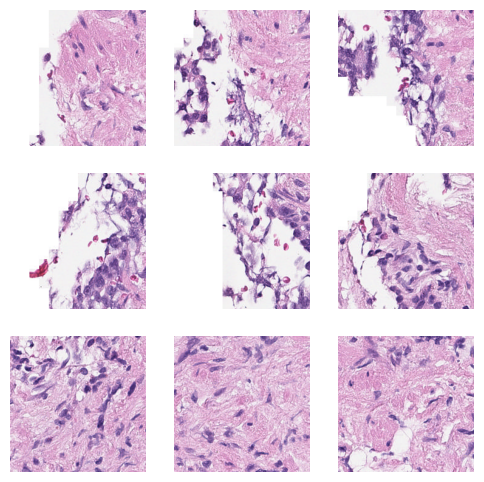

In [28]:
import matplotlib.pyplot as plt

def show_patches(patches):
    plt.figure(figsize=(6,6))
    for i in range(min(9, len(patches))):
        plt.subplot(3,3,i+1)
        plt.imshow(patches[i])
        plt.axis('off')
    plt.show()
    
show_patches(patches)

## Graph Construction

- Nodes = patches
- Edges = spatial neighbors

In [29]:
from sklearn.neighbors import kneighbors_graph

def build_graph(coords, k=6):
    A = kneighbors_graph(coords, k, mode='distance')
    return A

A = build_graph(coords)

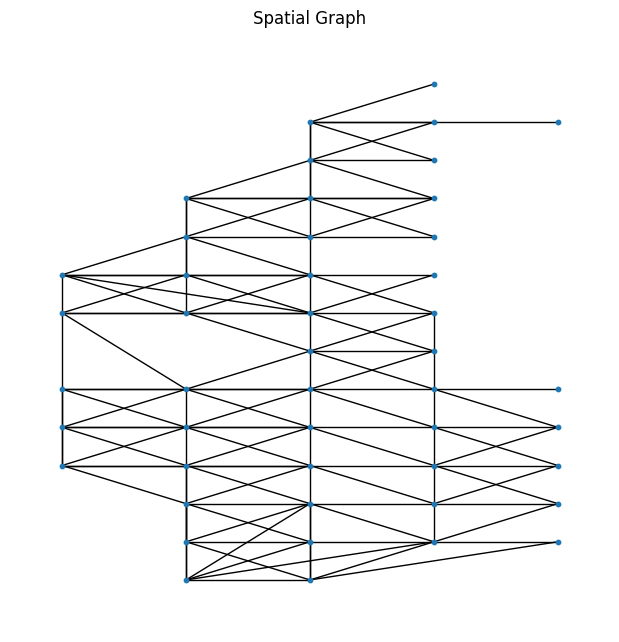

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

def visualize_graph(coords, A, n=200):
    G = nx.Graph()
    edges = np.vstack(A.nonzero())[:, :n]
    G.add_edges_from(edges.T)
    pos = {i: coords[i] for i in range(len(coords))}
    plt.figure(figsize=(6,6))
    nx.draw(G, pos, node_size=10)
    plt.title("Spatial Graph")
    plt.show()
    
visualize_graph(coords, A)

In [31]:
def compute_pagerank(A):
    G = nx.from_scipy_sparse_array(A)
    pr = nx.pagerank(G, alpha=0.85)
    return np.array([pr[i] for i in range(len(pr))])

pr = compute_pagerank(A)
print(pr)

[0.00321949 0.00291257 0.00342662 0.00352868 0.00339177 0.00355901
 0.00290626 0.00335676 0.00366603 0.00348809 0.00346415 0.00279709
 0.00331714 0.00282541 0.00334451 0.00330739 0.00260203 0.00437403
 0.00367711 0.00371898 0.00376271 0.00329213 0.00453208 0.00384318
 0.00270263 0.00380579 0.00276518 0.00324608 0.00345357 0.00308699
 0.00316285 0.00321659 0.00326762 0.00370332 0.00373119 0.00276634
 0.00272987 0.00427572 0.00350614 0.00368092 0.00272678 0.00322516
 0.00369591 0.00312348 0.00336532 0.0027919  0.00282246 0.00282146
 0.00333984 0.00284809 0.00274216 0.00360662 0.0034728  0.00408486
 0.00345475 0.00304368 0.00305969 0.0036543  0.00312864 0.00338118
 0.00278176 0.00285649 0.00287086 0.00338486 0.00287876 0.00274629
 0.00359081 0.00346132 0.00340935 0.0034147  0.00364243 0.00369812
 0.00276585 0.00327129 0.00298694 0.00313238 0.00428086 0.00276318
 0.00374984 0.0033161  0.00286629 0.00329644 0.00320772 0.00361579
 0.00412383 0.00405895 0.00339892 0.00342179 0.00369581 0.0030

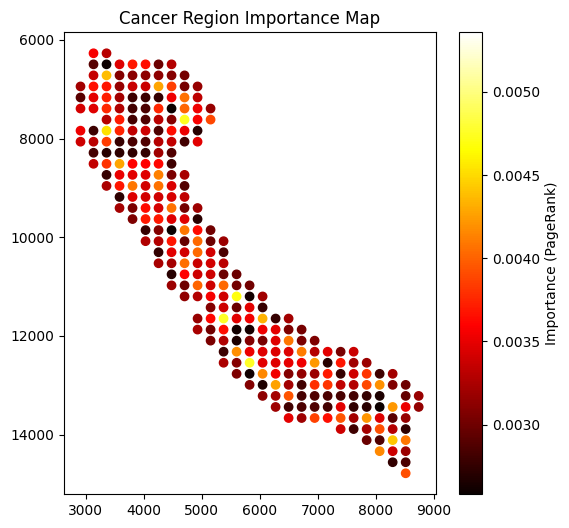

In [ ]:
def visualize_heatmap(coords, pr):
    x = [c[0] for c in coords]
    y = [c[1] for c in coords]

    plt.figure(figsize=(6,6))
    plt.scatter(x, y, c=pr, cmap='hot')
    plt.colorbar(label="Importance (PageRank)")
    plt.title("Cancer Region Importance Map")
    plt.gca().invert_yaxis()
    plt.show()
    
visualize_heatmap(coords, pr)

---

### Overlaying heatmap on WSI

1. Map patch → WSI coordinates
2. Gaussian smoothing 
3. Thresholding
4. Overlay

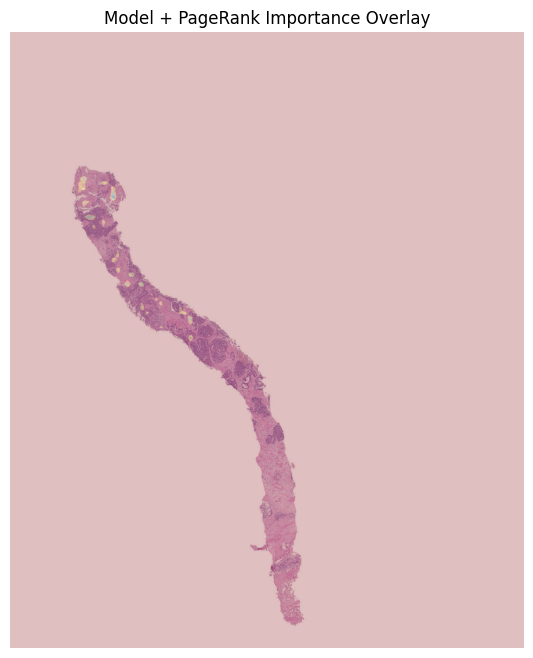

In [ ]:
import openslide
import numpy as np
import matplotlib.pyplot as plt
import cv2

def overlay_heatmap(slide_path, coords, importance, patch_size=224, downsample=32):
    slide = openslide.OpenSlide(slide_path)
    level = slide.get_best_level_for_downsample(downsample)
    w, h = slide.level_dimensions[level]

    wsi_img = slide.read_region((0, 0), level, (w, h))
    wsi_img = np.array(wsi_img)[:, :, :3]

    heatmap = np.zeros((h, w))
    scale = slide.level_downsamples[level]
    for (x, y), score in zip(coords, importance):

        x_s = int(x / scale)
        y_s = int(y / scale)
        p_s = int(patch_size / scale)

        heatmap[y_s:y_s+p_s, x_s:x_s+p_s] = score

    # NOW apply smoothing (correct order)
    heatmap = cv2.GaussianBlur(heatmap, (31,31), 0)

    # enhance
    heatmap = heatmap ** 2

    # threshold
    heatmap[heatmap < 0.3] = 0

    heatmap_color = cv2.applyColorMap(
        (heatmap * 255).astype(np.uint8),
        cv2.COLORMAP_JET
    )

    overlay = cv2.addWeighted(wsi_img, 0.75, heatmap_color, 0.25, 0)
    plt.figure(figsize=(8,8))
    plt.imshow(overlay)
    plt.title("Model + PageRank Importance Overlay")
    plt.axis('off')
    plt.show()
    
slide_path = "../data/panda/001c62abd11fa4b57bf7a6c603a11bb9.tiff"

overlay_heatmap(slide_path, coords, importance)